# Split data and train a logistic regression model to predict heart status

This code is adapted from Weishan Li used to train the compound screen models in [3a.train_dmso_logistic_regression_models](../../3a.train_dmso_logistic_regression_models/).


> NOTE: In this validation plate, the class previously known as "healthy" is named "nonfailing" in the platemap metadata. Because it is such a small difference, we will not rename the class but keep the encoding the same (e.g., failing is 0, healthy/nonfailing is 1).

## Import libraries

In [1]:
import json
import pathlib
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from joblib import Parallel, delayed

sys.path.append("../../3a.train_dmso_logistic_regression_models/src")
from cfret_ml.data_split_utils import (
    salt_seed,
    split_summary,
    stratified_fold_split,
    string_to_int_seed,
)
from cfret_ml.data_utils import split_and_prep_data
from cfret_ml.orchestrator import process_model_fitting


## Set paths

In [2]:
# Set random state for the whole notebook to ensure reproducibility
random_state = 0
random.seed(random_state)
np.random.seed(random_state)

# Path to directory with feature selected profiles
path_to_feature_selected_data = pathlib.Path().home() / "mnt" / "bandicoot" /\
    "CFReT_screening_data" / "validation_profiles"
if not path_to_feature_selected_data.exists() and\
    not path_to_feature_selected_data.is_dir():
    raise FileNotFoundError(
        f"Directory {path_to_feature_selected_data} does not exist or is not a directory."
    )

# Make directory for split data
datasplit_dir = pathlib.Path(".") / "datasplits"
datasplit_dir.mkdir(exist_ok=True, parents=True)


In [3]:
sc_profile_folder = (path_to_feature_selected_data / "single_cell_profiles").resolve()
if not sc_profile_folder.exists() or not sc_profile_folder.is_dir():
    raise FileNotFoundError(
        f"Directory {sc_profile_folder} does not exist or is not a directory."
    )

plate_files = [
    f
    for f in sc_profile_folder.glob("*_sc_feature_selected.parquet")
    if f.is_file()
]
if len(plate_files) != 1:
    raise ValueError(
        f"Expected exactly one feature selected profile for the validation plate, found {len(plate_files)}."
    )

plate_file = plate_files[0]

DMSO_df = (
    pl.scan_parquet(plate_file)
    .filter(pl.col("Metadata_treatment") == "DMSO")
    .collect(engine="cpu")
    .to_pandas()
)
if DMSO_df.empty:
    raise ValueError(f"No DMSO rows found for {plate_file.stem}.")

print(f"Collected {len(DMSO_df)} DMSO single cells for {plate_file.stem}.")


Collected 1480 DMSO single cells for CARD-CelIns-CX7_260803130001_sc_feature_selected.


In [4]:
control_cell_counts = (
    DMSO_df
    .groupby(['Metadata_treatment', 'Metadata_Well', 'Metadata_Plate', 'Metadata_cell_type'])
    .size()
    .reset_index(name='row_count')
)

control_cell_counts.to_csv(datasplit_dir / 'control_cell_counts.csv', index=False)
control_cell_counts.head(10)


,Metadata_treatment,Metadata_Well,Metadata_Plate,Metadata_cell_type,row_count
0,DMSO,B02,CARD-CelIns-CX7_260803130001,nonfailing,209
1,DMSO,B05,CARD-CelIns-CX7_260803130001,nonfailing,170
2,DMSO,B08,CARD-CelIns-CX7_260803130001,nonfailing,205
3,DMSO,B11,CARD-CelIns-CX7_260803130001,nonfailing,241
4,DMSO,E02,CARD-CelIns-CX7_260803130001,failing,108
5,DMSO,E05,CARD-CelIns-CX7_260803130001,failing,217
6,DMSO,E08,CARD-CelIns-CX7_260803130001,failing,205
7,DMSO,E11,CARD-CelIns-CX7_260803130001,failing,125


In [5]:
# Set the output directory
plate_repr = plate_file.stem
plate_output_dir = datasplit_dir / plate_repr
plate_output_dir.mkdir(exist_ok=True, parents=True)

# Skip regenerating datasplits if they already exist. The split is seeded off the
# plate name (see salt_seed/string_to_int_seed below), so a rerun would produce
# identical folds anyway -- this just avoids redoing the work and re-triggering
# a full retrain downstream.
existing_fold_files = sorted(plate_output_dir.glob("fold_*_split.json"))
dmso_parquet_path = plate_output_dir / "DMSO.parquet"
encoding_path = datasplit_dir / "cell_type_encoding.json"

if existing_fold_files and dmso_parquet_path.exists() and encoding_path.exists():
    print(
        f"Datasplits already exist for {plate_repr} "
        f"({len(existing_fold_files)} folds found). Skipping split generation."
    )
else:
    # Set the random seed for the plate based on its name to ensure reproducibility
    plate_name_salt = string_to_int_seed(plate_repr)
    salted_seed = salt_seed(random_state, plate_name_salt)

    # Check to confirm two classes are present
    if DMSO_df["Metadata_cell_type"].nunique() < 2:
        raise ValueError(f"Only one cell type present in {plate_repr}. Cannot perform stratified split.")

    # Perform stratified fold split (grouped by well, stratified by cell type)
    split = stratified_fold_split(
        DMSO_df,
        group_col="Metadata_Well",
        class_col="Metadata_cell_type",
        random_state=salted_seed,
    )

    # Save the split information for each fold
    for i, (train_index, test_index) in enumerate(split):
        fold_record = {
            "fold": i,
            "train_index": train_index.tolist(),
            "test_index": test_index.tolist(),
            "seed": salted_seed,
        }
        fold_record.update(
            split_summary(
                DMSO_df,
                train_index,
                test_index,
                group_col="Metadata_Well",
                label_col="Metadata_cell_type",
            )
        )

        fold_documentation_path = plate_output_dir / f"fold_{i}_split.json"
        with open(fold_documentation_path, "w") as f:
            json.dump(fold_record, f, indent=4)

        held_out_wells = sorted(DMSO_df.loc[test_index, "Metadata_Well"].unique())
        print(f"\tFold {i}: held out wells {held_out_wells}")

    print(f"Datasplits written for {plate_repr}.")

    DMSO_df.to_parquet(dmso_parquet_path, index=False)

    # Save cell type encoding for consistent model fitting and interpretation
    unique_cell_types = sorted(DMSO_df["Metadata_cell_type"].unique())
    cell_type_encoding = {ct: i for i, ct in enumerate(unique_cell_types)}
    print("Cell type encoding:")
    for ct, enc in cell_type_encoding.items():
        print(f"\t{ct}: {enc}")

    with open(encoding_path, "w") as f:
        json.dump(cell_type_encoding, f)


Datasplits already exist for CARD-CelIns-CX7_260803130001_sc_feature_selected (4 folds found). Skipping split generation.


## Set variables for model training

In [6]:
metadata_prefix = "Metadata_"
label_col = "Metadata_cell_type"

fitted_model_dir = pathlib.Path(".") / "models"
fitted_model_dir.mkdir(exist_ok=True)

eval_plot_dir = pathlib.Path(".") / "eval_plots"
eval_plot_dir.mkdir(exist_ok=True)


## Train logit model

In [7]:
# Load cell type encoding used during data splitting
encoding_path = datasplit_dir / "cell_type_encoding.json"
if not encoding_path.exists():
    raise FileNotFoundError(f"Cell type encoding file not found: {encoding_path}")
encoding_dict = json.loads(encoding_path.read_text())
print(f"Loaded cell type encoding for {len(encoding_dict)} cell types.")

# Locate the single plate's datasplit directory
plate_level_splits = [p for p in datasplit_dir.iterdir() if p.is_dir()]
if len(plate_level_splits) != 1:
    raise ValueError(
        f"Expected exactly one plate-level datasplit directory in {datasplit_dir}, found {len(plate_level_splits)}."
    )
plate_dir = plate_level_splits[0]
plate_repr = plate_dir.name

# Load split files
split_json_files = list(plate_dir.glob("fold_*_split.json"))
if not split_json_files:
    raise FileNotFoundError(f"No fold split files found in {plate_dir}.")
dmso_parquet = plate_dir / "DMSO.parquet"
if not dmso_parquet.exists():
    raise FileNotFoundError(f"DMSO profiles not found in {plate_dir}.")

dmso_df = pd.read_parquet(dmso_parquet)
dmso_df['Metadata_cell_type'] = dmso_df['Metadata_cell_type'].map(encoding_dict)

print(f"Queueing tasks for plate {plate_repr} with {len(split_json_files)} splits")

# Make directories for fitted models and eval plots for this plate
plate_fitted_model_dir = fitted_model_dir / plate_repr
plate_fitted_model_dir.mkdir(exist_ok=True)

plate_eval_plot_dir = eval_plot_dir / plate_repr
plate_eval_plot_dir.mkdir(exist_ok=True)

# Initialize train/test splits with None to ensure correct ordering by fold index
train_splits = [None] * len(split_json_files)
test_splits = [None] * len(split_json_files)

tasks = []
split_rows = []

# Process each split JSON file to extract train/test indices and summary statistics
for split_json in split_json_files:

    with open(split_json, "r") as f:
        split_info = json.load(f)

    train_splits[split_info['fold']] = split_info["train_index"]
    test_splits[split_info['fold']] = split_info["test_index"]

    split_row = {
        "plate": plate_repr,
        "fold": split_info["fold"],
        "train_n": len(split_info["train_index"]),
        "test_n": len(split_info["test_index"]),
        **{
            f"{split}_{label}": split_info[split][label]
            for split in ["train", "test"]
            for label in split_info[split]
        }
    }
    split_rows.append(split_row)

# Iterate through the splits in order of fold index to create model fitting tasks
for fold_idx, (train_idx, test_idx) in enumerate(zip(train_splits, test_splits)):

    if train_idx is None or test_idx is None:
        continue

    # Helper function to create the train/test profiles, labels and shuffled labels for a given split
    (
        train_profiles,
        test_profiles,
        train_labels,
        test_labels,
        train_labels_shuffled,
    ) = split_and_prep_data(
        dmso_df,
        train_idx,
        test_idx,
        shuffle_random_state=random_state,
        metadata_prefix=metadata_prefix,
        label_col=label_col
    )

    # ensure both train and test sets have at least some representation of both classes
    n_pos = train_labels.sum()
    n_neg = len(train_labels) - n_pos
    min_class = min(n_pos, n_neg)
    if min_class <= 50 or (n_pos + n_neg <= 100):
        print(f"\tNot enough train samples in plate {plate_repr} fold {fold_idx}")
        continue

    n_pos_test = test_labels.sum()
    n_neg_test = len(test_labels) - n_pos_test
    if n_pos_test == 0 or n_neg_test == 0:
        print(f"\tTest set missing a class in plate {plate_repr} fold {fold_idx}")
        continue

    # Create two tasks for this split - one with original labels and one with shuffled labels
    for shuffle_status, labels in zip(
        ["original", "shuffled"],
        [train_labels, train_labels_shuffled]
    ):
        tasks.append({
            "train_profiles": train_profiles,
            "test_profiles": test_profiles,
            "labels": labels,
            "test_labels": test_labels,
            "shuffle_status": shuffle_status,
            "plate_repr": plate_repr,
            "fold": fold_idx,
            "plate_fitted_model_dir": plate_fitted_model_dir,
            "plate_eval_plot_dir": plate_eval_plot_dir,
            "random_state": random_state
        })

# Run all the model fitting tasks in parallel and collect results into a dataframe, then merge with the split summary statistics and save to CSV
print(f"Executing {len(tasks)} model fitting tasks in parallel (n_jobs=8)...")
results = Parallel(n_jobs=8)(delayed(process_model_fitting)(**kwargs) for kwargs in tasks)

results_df = pd.DataFrame(results)
split_df = pd.DataFrame(split_rows)
enriched_df = pd.merge(
    results_df,
    split_df,
    on=["plate", "fold"],
    how="left",
)
enriched_df.to_csv(eval_plot_dir / "model_fit_summary.csv", index=False)


Loaded cell type encoding for 2 cell types.
Queueing tasks for plate CARD-CelIns-CX7_260803130001_sc_feature_selected with 4 splits
Executing 8 model fitting tasks in parallel (n_jobs=8)...
	Previous attempt to fit statsmodels Logit for plate CARD-CelIns-CX7_260803130001_sc_feature_selected fold 2 original failed to converge, skipping.
	Loaded existing fitted model for plate CARD-CelIns-CX7_260803130001_sc_feature_selected fold 0 shuffled from checkpoint.
	Loaded existing fitted model for plate CARD-CelIns-CX7_260803130001_sc_feature_selected fold 1 original from checkpoint.
	Loaded existing fitted model for plate CARD-CelIns-CX7_260803130001_sc_feature_selected fold 1 shuffled from checkpoint.
	Previous attempt to fit statsmodels Logit for plate CARD-CelIns-CX7_260803130001_sc_feature_selected fold 0 original failed to converge, skipping.
	Loaded existing fitted model for plate CARD-CelIns-CX7_260803130001_sc_feature_selected fold 2 shuffled from checkpoint.
	Loaded existing fitted mo

## Visualize model performance across folds

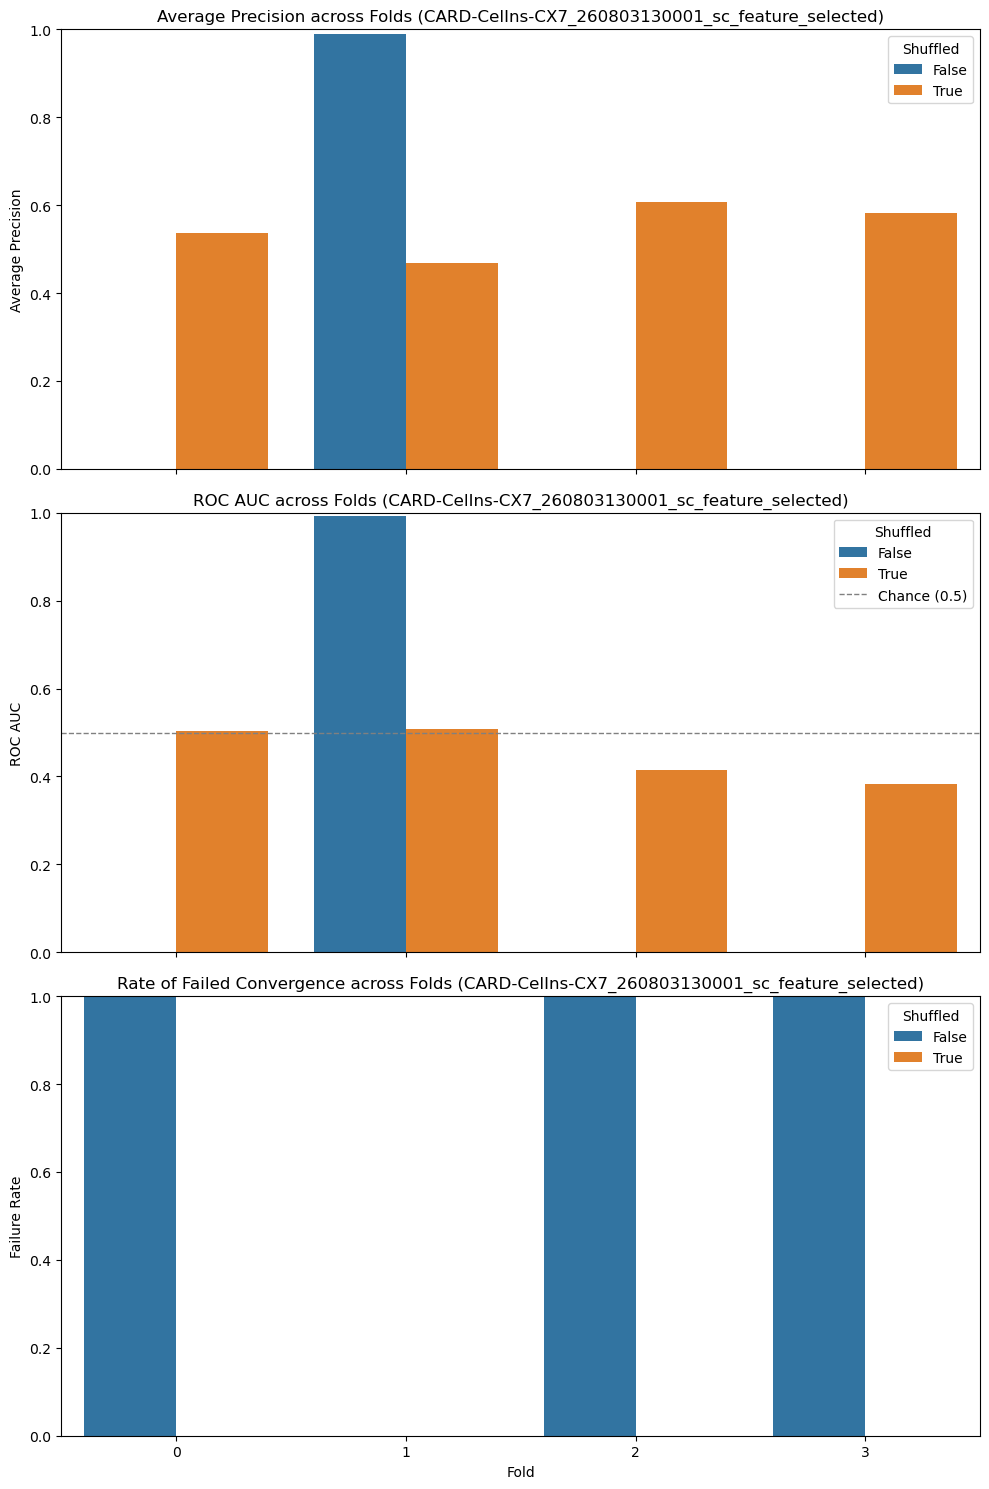

In [9]:
enriched_df['convergence_failed'] = (
    enriched_df['average_precision'].isna() | enriched_df['roc_auc'].isna()
)

# Calculate convergence failure rate per fold, split by shuffle status so a
# systematic failure of the "true" (non-shuffled) model is visible on its own
failure_rates = (
    enriched_df.groupby(['fold', 'shuffled'])['convergence_failed']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

# With only one plate, each (fold, shuffled) pair has a single model fit --
# not a distribution -- so barplots (one bar per pair) are used instead of
# boxplots, which would otherwise render as invisible slivers for n=1 groups.
# A missing bar means that model failed to converge (see convergence_failed
# panel below), not a value of zero.

# 1. Barplot for Average Precision
sns.barplot(
    data=enriched_df,
    x='fold',
    y='average_precision',
    hue='shuffled',
    ax=axes[0]
)
axes[0].set_title(f'Average Precision across Folds ({plate_repr})')
axes[0].set_ylabel('Average Precision')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Shuffled', loc='upper right')

# 2. Barplot for ROC AUC
sns.barplot(
    data=enriched_df,
    x='fold',
    y='roc_auc',
    hue='shuffled',
    ax=axes[1]
)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance (0.5)')
axes[1].set_title(f'ROC AUC across Folds ({plate_repr})')
axes[1].set_ylabel('ROC AUC')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Shuffled', loc='upper right')

# 3. Barplot for failed convergence rate, split by shuffle status
sns.barplot(
    data=failure_rates,
    x='fold',
    y='convergence_failed',
    hue='shuffled',
    ax=axes[2]
)
axes[2].set_title(f'Rate of Failed Convergence across Folds ({plate_repr})')
axes[2].set_ylabel('Failure Rate')
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Fold')
axes[2].legend(title='Shuffled', loc='upper right')

plt.tight_layout()
plt.show()

fig.savefig(
    eval_plot_dir / "metric_convergence_summary.png",
    dpi=300,
    bbox_inches="tight"
)
